In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [11]:
from collections import Counter
from sklearn.datasets import make_classification 
x,y=make_classification(n_samples=10000,n_features=2,n_clusters_per_class=1,n_redundant=0,weights=[0.99],random_state=10)


<Axes: xlabel='x1', ylabel='x2'>

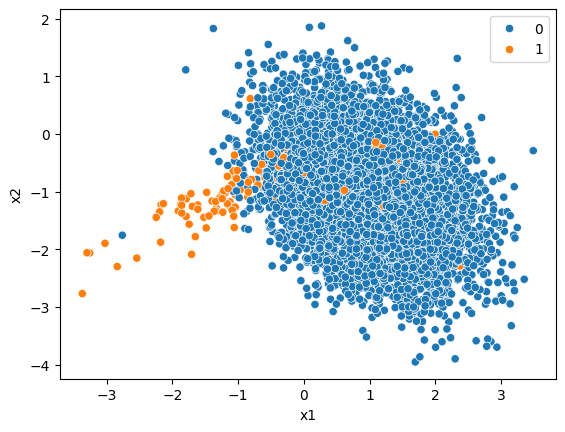

In [12]:
df = pd.DataFrame(x, columns=["x1", "x2"])

sns.scatterplot(
    x=df["x1"],
    y=df["x2"],
    hue=y
)



In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)




In [14]:
## we have a completely imbalanced dataset so we are going to specify the class_weight dictionary
class_weight=[{0:w,1:y}for w in [1,10,50,100] for y in [1,10,50,100]]

In [15]:
from sklearn.linear_model import LogisticRegression
models=LogisticRegression()
c_values=[100,10,1.0,0.1,0.01]
penalty=['l1','l2','elasticnet']
solver=['newton-cg','ibfgs','liblinear','sag','saga']



In [17]:
params=dict(penalty=penalty,solver=solver,C=c_values,class_weight=class_weight)

In [18]:
from sklearn.model_selection import RandomizedSearchCV
grid=RandomizedSearchCV(estimator=models,param_distributions=params,scoring='accuracy',cv=5,n_jobs=-1)

In [19]:
grid.fit(x_train,y_train)##internally does cross validation

/Users/yashkumar/Desktop/ai ml code/venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/yashkumar/Desktop/ai ml code/venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/yashkumar/Desktop/ai ml code/venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/yashkumar/Desktop/ai ml code/venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/yashkumar/Desktop/ai ml code/venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
35 fits failed out of a total of 50.
The score 

RandomizedSearchCV(cv=5, estimator=LogisticRegression(), n_jobs=-1,
                   param_distributions={'C': [100, 10, 1.0, 0.1, 0.01],
                                        'class_weight': [{0: 1, 1: 1},
                                                         {0: 1, 1: 10},
                                                         {0: 1, 1: 50},
                                                         {0: 1, 1: 100},
                                                         {0: 10, 1: 1},
                                                         {0: 10, 1: 10},
                                                         {0: 10, 1: 50},
                                                         {0: 10, 1: 100},
                                                         {0: 50, 1: 1},
                                                         {0: 50, 1: 10},
                                                         {0: 50, 1: 50},
                                                         {0: 50, 1: 100},
                                                         {0: 100, 1: 1},
                                                         {0: 100, 1: 10},
                                                         {0: 100, 1: 50},
                                                         {0: 100, 1: 100}],
                                        'penalty': ['l1', 'l2', 'elasticnet'],
                                        'solver': ['newton-cg', 'ibfgs',
                                                   'liblinear', 'sag',
                                                   'saga']},
                   scoring='accuracy')

In [20]:
grid.best_params_

{'solver': 'liblinear',
 'penalty': 'l2',
 'class_weight': {0: 100, 1: 50},
 'C': 100}

In [21]:
grid.best_score_

np.float64(0.9865714285714284)

In [23]:

from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
y_pred=grid.predict(x_test)
print(accuracy_score(y_pred,y_test))
print(classification_report(y_pred,y_test))
print(confusion_matrix(y_pred,y_test))

0.987
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      2992
           1       0.17      1.00      0.29         8

    accuracy                           0.99      3000
   macro avg       0.59      0.99      0.64      3000
weighted avg       1.00      0.99      0.99      3000

[[2953   39]
 [   0    8]]


# NOW AS WE KNOW : 
- THRESHOLD VALUE IS BY DEFAULT 0.5 
- WE ARE GOING TO SEE THE USE CASES WHEN ITS NOT 0.5 AND WE ARE GOING TO DETERMINE THAT CHANGE

- AUC SCORE - 
Socho:
Tumhara model ek security guard hai
Uska kaam: chor aur normal aadmi ko pehchanna
Model har bande ko ek score deta hai:
High score → chor hone ka chance zyada
Low score → normal hone ka chance zyada

- ROC CURVE
Real-life example se samjho 🚨
Socho:

Airport security scanner

Threshold = scanner kitna strict hai

Case 1: Scanner bahut strict

Sabko suspect bolega
Chor bhi pakde jayenge ✅ (TPR high)
Normal log bhi fasenge ❌ (FPR high)
Case 2: Scanner bahut loose
Normal log safe
Chor bhi nikal jayenge 😬
TPR low, FPR low
👉 ROC curve yahi trade-off dikhati hai
ROC Curve ka shape ka matlab 📈
✅ Curve jitni top-left ke paas
→ model utna hi better
❌ Diagonal line (45°)
→ random guessing
→ AUC = 0.5 (coin toss 🎲)

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from matplotlib import pyplot

In [29]:
x,y=make_classification(n_samples=10000,n_classes=2,random_state=10)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)


In [ ]:
#WE HAVE CREATED ADUMMY MODEL WHICH GIVES TEST VALUE AS 0 FOR ALL THE VALUE OF INPUTS .
dummy_model_prob=[0 for _ in range(len(y_test)) ]
dummy_model_prob

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,


In [31]:
model=LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

In [35]:
model_prob=model.predict_proba(x_test) # we get the predict probablity for x_test
model_prob

array([[0.06630202, 0.93369798],
       [0.35681186, 0.64318814],
       [0.0293022 , 0.9706978 ],
       ...,
       [0.13468446, 0.86531554],
       [0.01067049, 0.98932951],
       [0.35409733, 0.64590267]], shape=(3000, 2))

In [36]:
# now we are going to tirim the vlaue of output to 1 variable abhi 2 ki milri thi na ... 
# abhi voo0 and 1 dono ki dera tha
# ab main ek ki hi lunga

model_prob=model_prob[:,1]

In [37]:
#3 now calculate the score
dummy_model_auc=roc_auc_score(y_test,dummy_model_prob)
model_auc_score=roc_auc_score(y_test,model_prob)

print(dummy_model_auc)
print(model_auc_score)


0.5
0.9591220661450925
